# 03 — Distribution Plots & Multi-Plot Grids
**Preetham's Seaborn Mastery Series**

Understanding feature distributions and joint pairwise relationships is fundamental in exploratory data analysis and probabilistic modeling.

### Notebook Contents:
1. **Univariate Distributions (`sns.histplot`, `sns.kdeplot`, `sns.ecdfplot`, `sns.rugplot`)**
2. **Bivariate & Multivariate Density Plots (2D `kdeplot`, 2D `histplot`)**
3. **Figure-Level Distribution Faceting (`sns.displot`)**
4. **Joint Plots & Marginal Distributions (`sns.jointplot`)**
5. **Pairwise Relationship Grids (`sns.pairplot`)**
6. **Advanced Custom Multi-Plot Grids (`JointGrid` & `PairGrid`)**
7. **Summary & Visual Selection Guide**


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")
%matplotlib inline

penguins = sns.load_dataset("penguins").dropna()
tips = sns.load_dataset("tips")
diamonds = sns.load_dataset("diamonds").sample(2000, random_state=42)

print("Penguins Data Shape:", penguins.shape)


Penguins Data Shape: (333, 7)


## 1. Univariate Distribution Visualizations

- `histplot()`: Frequency/density histogram with customizable bin width, elements (`bars`, `step`, `poly`), and KDE overlay.
- `kdeplot()`: Continuous Kernel Density Estimate with smoothing adjustment (`bw_adjust`) and filled areas.
- `ecdfplot()`: Empirical Cumulative Distribution Function — exact representation of distribution rank without binning bias.
- `rugplot()`: Small tick marks along axis showing individual continuous data points.


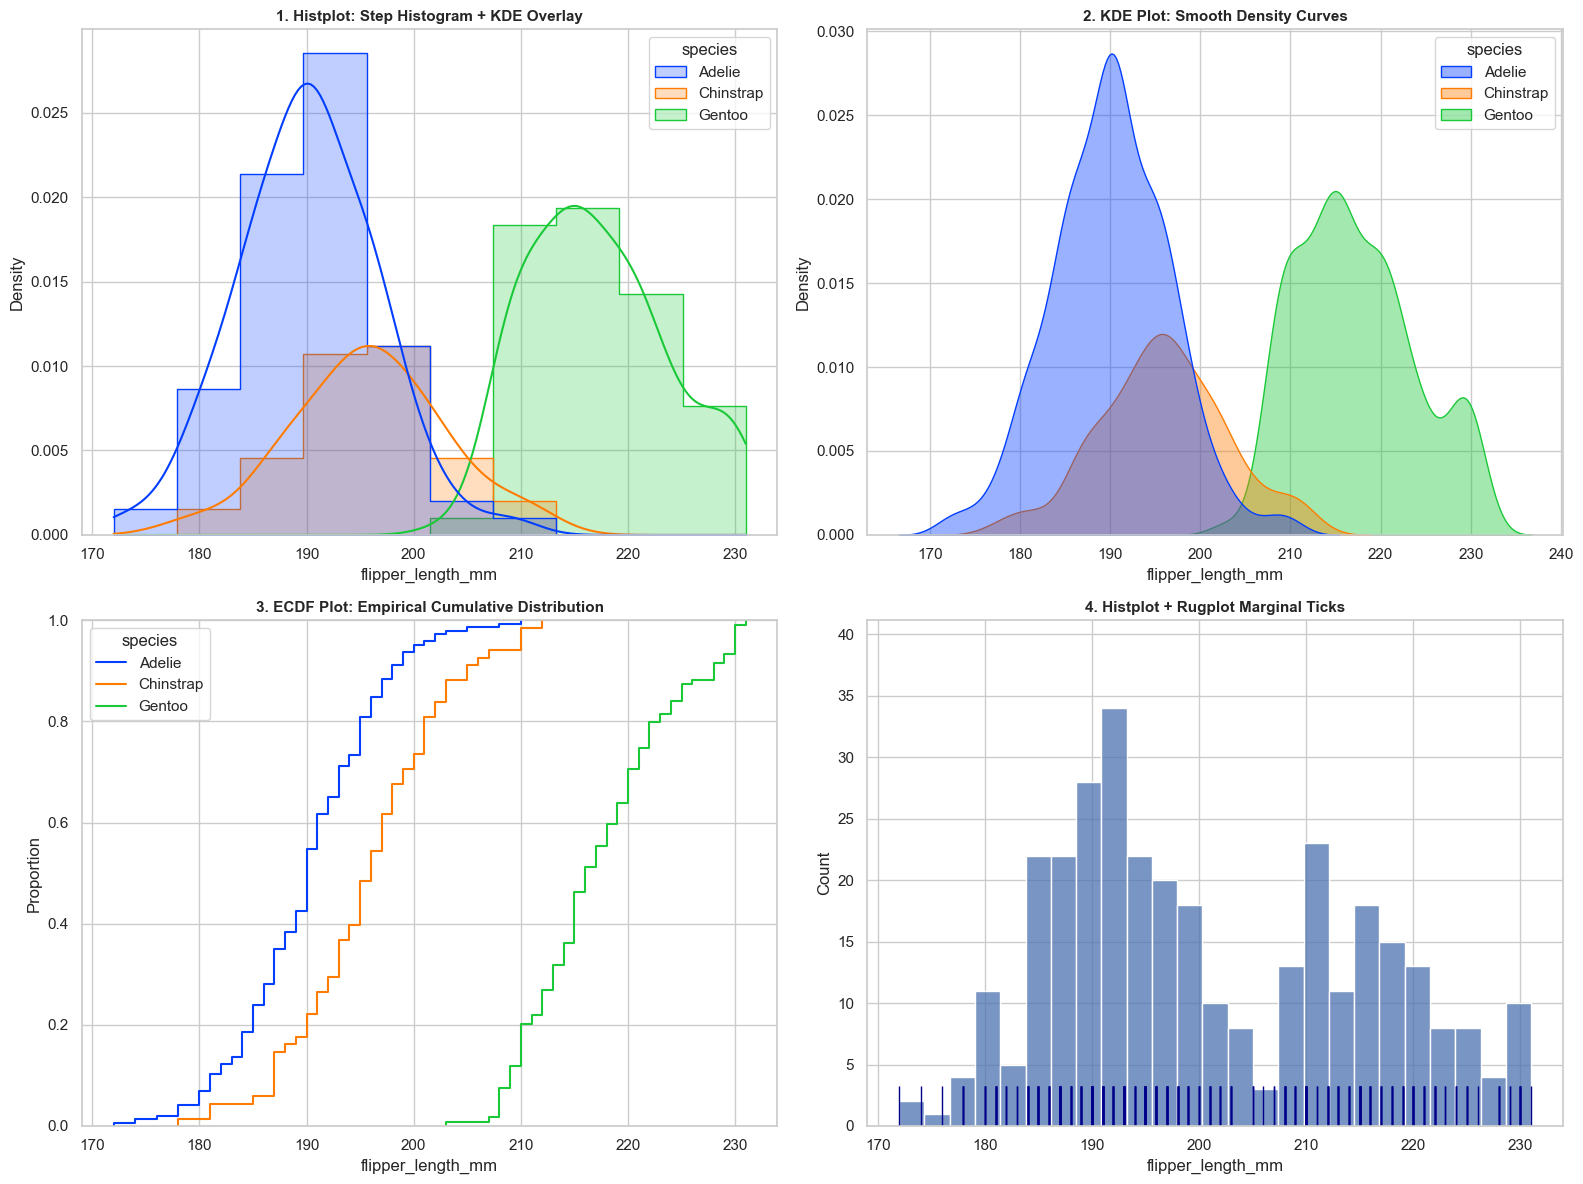

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histplot with KDE overlay & custom stat
sns.histplot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    kde=True,
    stat="density",
    element="step",
    palette="bright",
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Histplot: Step Histogram + KDE Overlay", fontsize=11, fontweight="bold")

# 2. KDE Plot with bandwidth tuning & fill
sns.kdeplot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    bw_adjust=0.75,
    fill=True,
    alpha=0.4,
    palette="bright",
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. KDE Plot: Smooth Density Curves", fontsize=11, fontweight="bold")

# 3. ECDF Plot
sns.ecdfplot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    palette="bright",
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. ECDF Plot: Empirical Cumulative Distribution", fontsize=11, fontweight="bold")

# 4. Histplot + Rugplot combination
sns.histplot(
    data=penguins,
    x="flipper_length_mm",
    color="#4c72b0",
    bins=25,
    ax=axes[1, 1]
)
sns.rugplot(
    data=penguins,
    x="flipper_length_mm",
    color="darkblue",
    height=0.08,
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Histplot + Rugplot Marginal Ticks", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 2. Bivariate & 2D Distribution Plots

Bivariate distributions reveal joint probabilities between two continuous variables simultaneously.
- 2D `kdeplot()`: Isodensity contours or smooth density gradient heatmaps.
- 2D `histplot()`: Rectangular or hexagonal binning for 2D density representation.


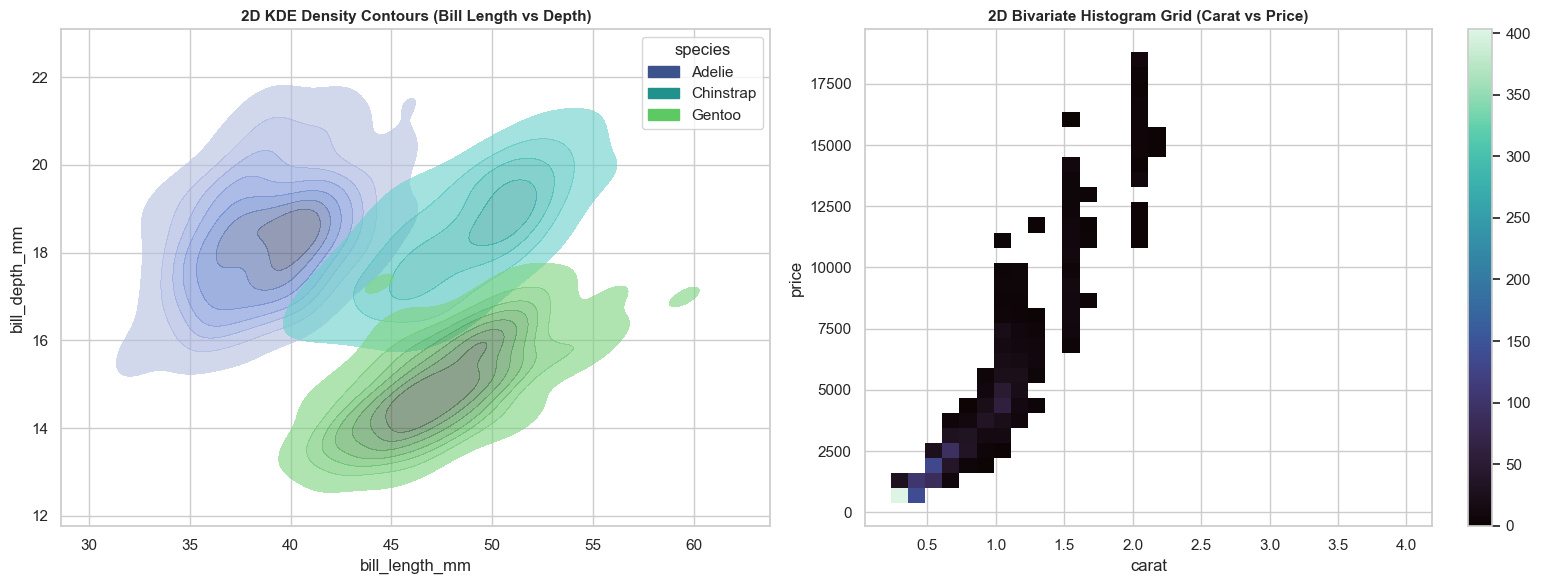

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2D KDE Contours with Fill
sns.kdeplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    fill=True,
    thresh=0.05,
    levels=8,
    alpha=0.6,
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("2D KDE Density Contours (Bill Length vs Depth)", fontsize=11, fontweight="bold")

# 2D Histplot Bivariate Heatmap Grid
sns.histplot(
    data=diamonds,
    x="carat",
    y="price",
    bins=30,
    pthresh=0.05,
    cmap="mako",
    cbar=True,
    ax=axes[1]
)
axes[1].set_title("2D Bivariate Histogram Grid (Carat vs Price)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 3. Figure-Level Distribution Faceting (`sns.displot`)

`displot()` provides unified multi-column and multi-row faceting across histograms, KDEs, and ECDFs.


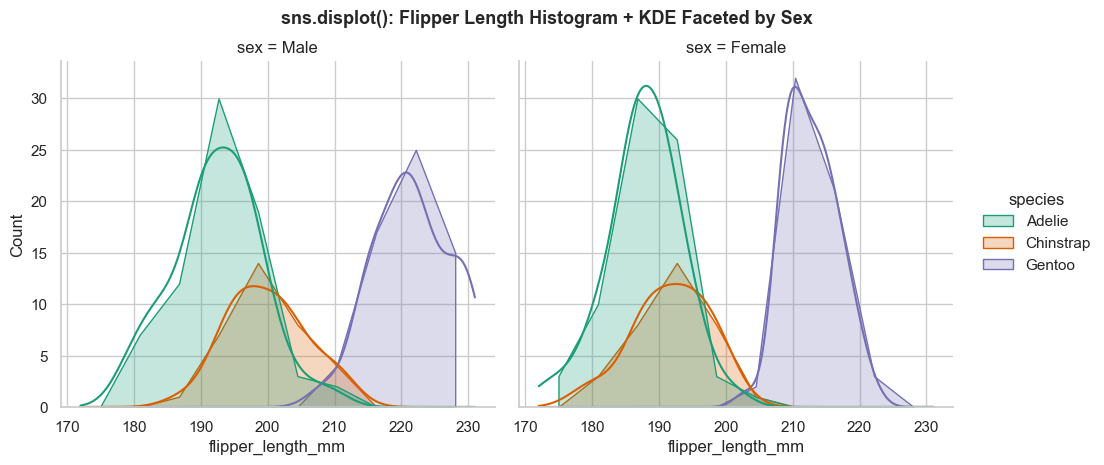

In [4]:
g = sns.displot(
    data=penguins,
    x="flipper_length_mm",
    hue="species",
    col="sex",
    kind="hist",
    kde=True,
    element="poly",
    height=4.5,
    aspect=1.1,
    palette="Dark2"
)
g.fig.suptitle("sns.displot(): Flipper Length Histogram + KDE Faceted by Sex", y=1.03, fontsize=13, fontweight="bold")
plt.show()


## 4. Joint Plots & Marginal Distributions (`sns.jointplot`)

`jointplot()` pairs a central bivariate plot with marginal univariate distributions along the top and right axes.
Available kinds: `'scatter'`, `'kde'`, `'hist'`, `'hex'`, `'reg'`, `'resid'`.


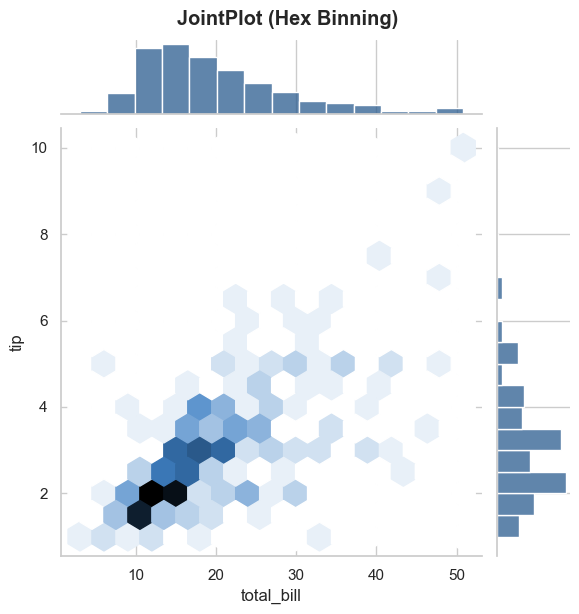

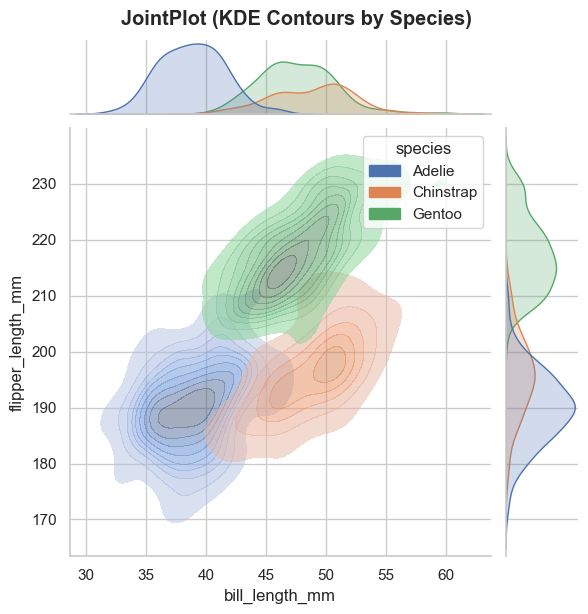

In [5]:
# JointPlot Kind 1: Hexagonal Binning for High Density Data
g1 = sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip",
    kind="hex",
    color="#2b5c8f",
    height=6
)
g1.fig.suptitle("JointPlot (Hex Binning)", y=1.02, fontweight="bold")
plt.show()

# JointPlot Kind 2: KDE Density Contours with Marginal KDEs
g2 = sns.jointplot(
    data=penguins,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    kind="kde",
    fill=True,
    alpha=0.5,
    height=6
)
g2.fig.suptitle("JointPlot (KDE Contours by Species)", y=1.02, fontweight="bold")
plt.show()


## 5. Pairwise Matrix Visualizations (`sns.pairplot`)

`pairplot()` plots pairwise scatter/KDE plots for all numeric features in a dataset in a grid layout.
- Use `corner=True` to hide duplicate upper triangular plots.
- Customize diagonal plots with `diag_kind='kde'` or `'hist'`.


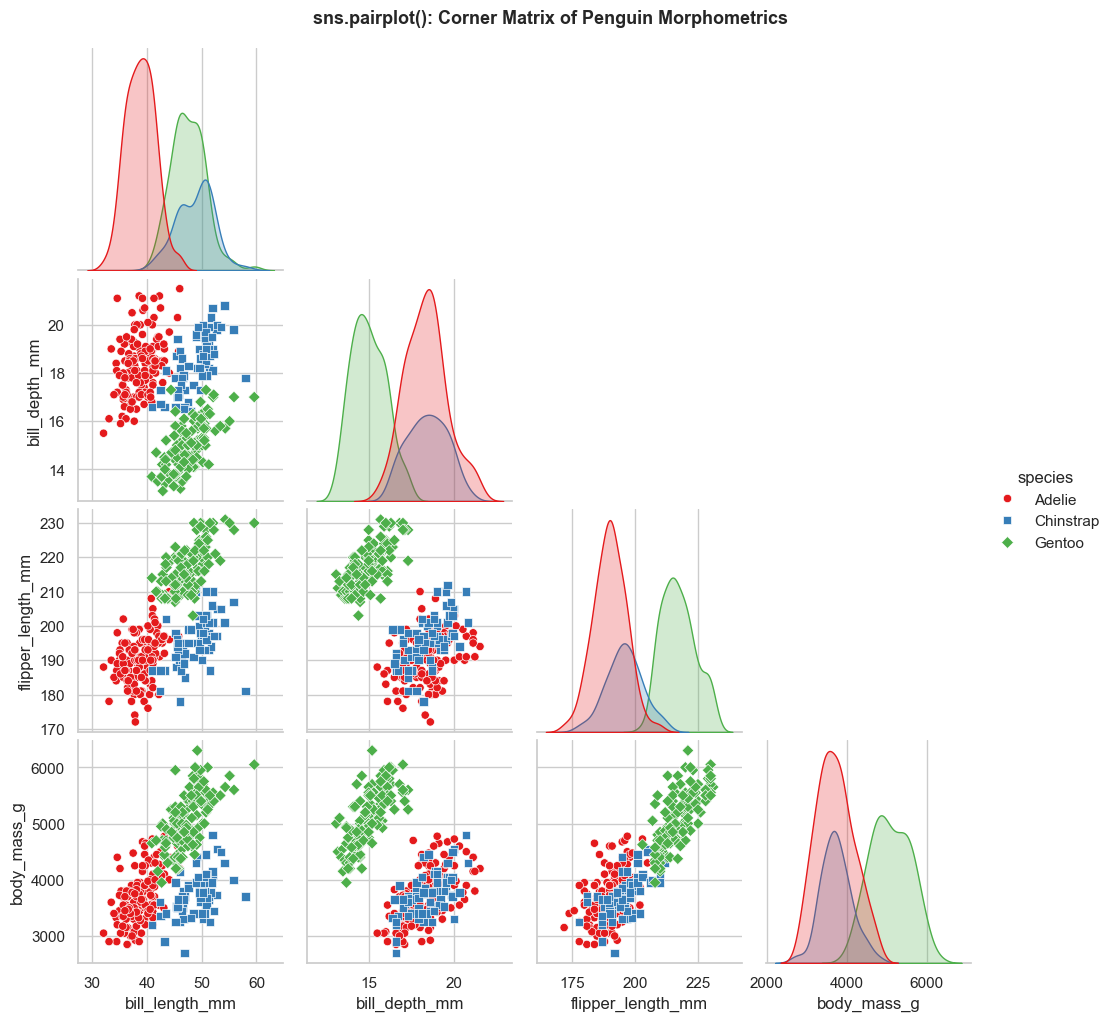

In [6]:
g = sns.pairplot(
    penguins,
    hue="species",
    corner=True,
    diag_kind="kde",
    palette="Set1",
    height=2.5,
    markers=["o", "s", "D"]
)
g.fig.suptitle("sns.pairplot(): Corner Matrix of Penguin Morphometrics", y=1.02, fontsize=13, fontweight="bold")
plt.show()


## 6. Advanced Custom Layouts with `JointGrid` & `PairGrid`

When built-in `jointplot` or `pairplot` presets are not enough, `JointGrid` and `PairGrid` give you 100% granular programmatic control over joint, marginal, upper, lower, and diagonal plot layers!


C:\Users\praveen\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:1883: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)
C:\Users\praveen\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:1889: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(y=self.y, ax=self.ax_marg_y, **kwargs)


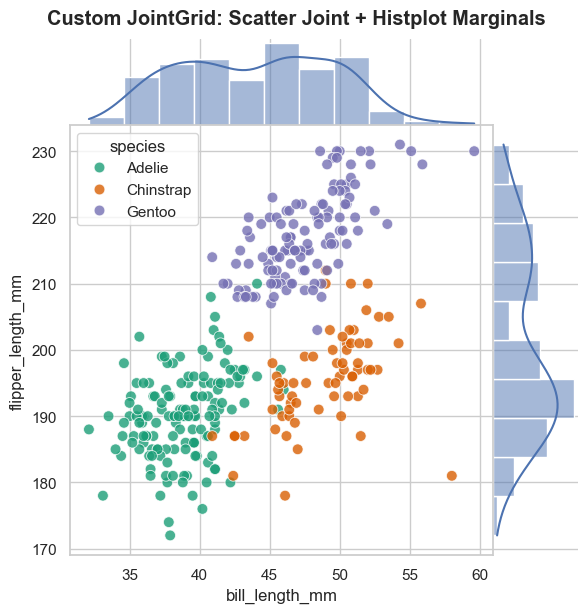

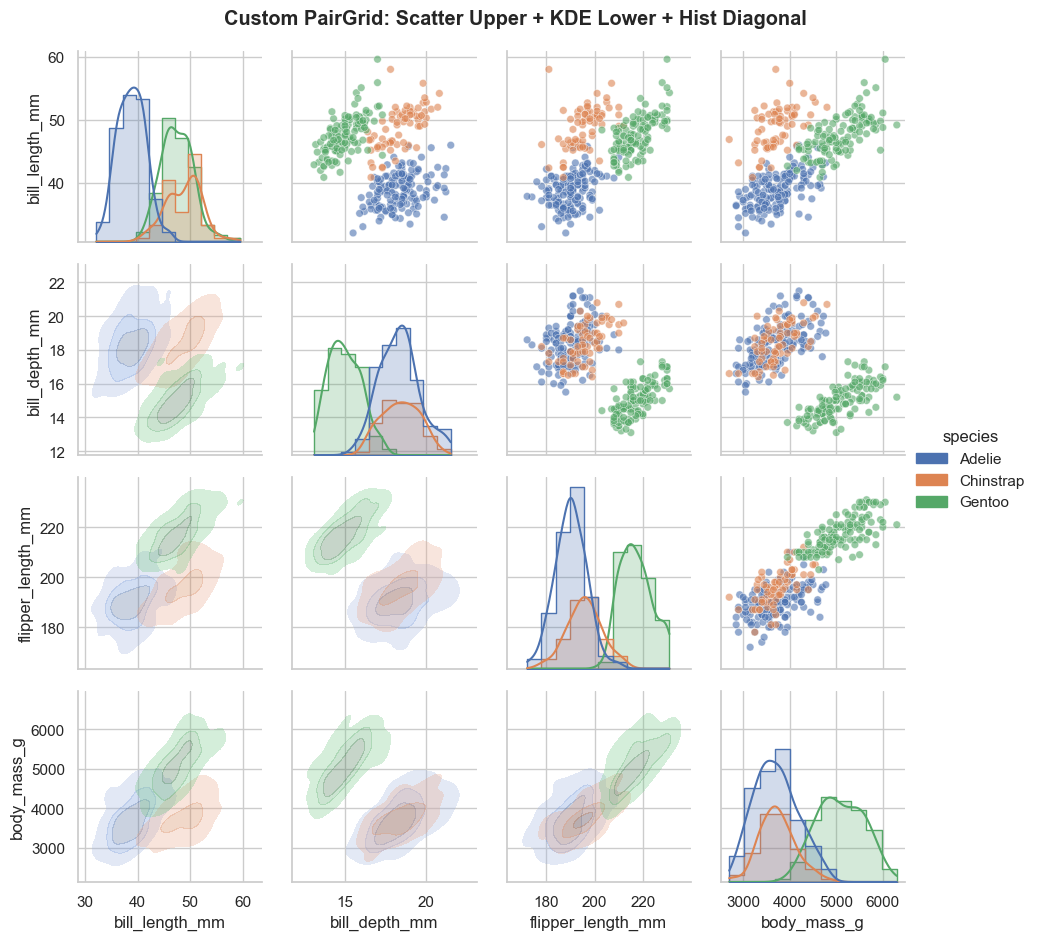

In [7]:
# 1. Custom JointGrid with Scatter Joint and Histplot Marginals
g_joint = sns.JointGrid(data=penguins, x="bill_length_mm", y="flipper_length_mm", space=0)
g_joint.plot_joint(sns.scatterplot, hue=penguins["species"], palette="Dark2", alpha=0.8, s=60)
g_joint.plot_marginals(sns.histplot, kde=True, palette="Dark2")
g_joint.fig.suptitle("Custom JointGrid: Scatter Joint + Histplot Marginals", y=1.02, fontweight="bold")
plt.show()

# 2. Custom PairGrid: KDE Lower, Scatter Upper, Hist Diagonal
g_pair = sns.PairGrid(penguins, hue="species", corner=False, height=2.3)
g_pair.map_upper(sns.scatterplot, alpha=0.6, s=30)
g_pair.map_lower(sns.kdeplot, fill=True, alpha=0.3, levels=4)
g_pair.map_diag(sns.histplot, kde=True, element="step")
g_pair.add_legend()
g_pair.fig.suptitle("Custom PairGrid: Scatter Upper + KDE Lower + Hist Diagonal", y=1.02, fontweight="bold")
plt.show()


## 7. Summary & Visual Selection Guide

- **Univariate Analysis**: Start with `histplot(kde=True)` for general shape, or `ecdfplot()` for precise quantile evaluation.
- **Bivariate Continuous**: Use `scatterplot()` for smaller samples, `jointplot(kind='hex')` or 2D `histplot` for dense observations.
- **Multivariate Matrix**: Use `pairplot(corner=True)` for initial feature exploration.
- **Programmatic Control**: Use `JointGrid` or `PairGrid` when mixing non-standard plot combinations.
